# Machine Learning explicado — Electric Motor Vibrations ⚡

En este cuaderno guía se vera, paso a paso, el flujo de *Machine Learning* Random Forest aplicado a un dataset de vibraciones de motor eléctrico. Creado por: Xozué Cabrera Mendivil, 
creditos para el autor del dataset utilizado: https://www.kaggle.com/datasets/amirberenji/electric-motor-vibrations-dataset?resource=download

**Qué incluye:**
1. Carga y exploración del dataset (EDA).
2. Limpieza básica y separación de variables (X, Y).
3. División *train/test* con estratificación.
4. Entrenamiento de un modelo de **Random Forest (clasificación)**.
5. Evaluación: *accuracy*, *classification report*, *confusion matrix*.
6. Imagenes **guardadas en PNG** para que se impriman/peguen bien en presentaciones.
7. Importancias de características y correlaciones.

> **Nota importante:** Ajusta la variable `FILE_PATH` a la ruta real de tu CSV. Si lo abres en Jupyter/Colab, recuerda subir primero el archivo o ponlo en tu disco. :)


## Requisitos y buenas prácticas de gráficos

- Utilizamos **matplotlib**, para evitar problemas de renderizado en exportaciones.
- Cada figura se **guarda a PNG** (carpeta `figs/`) con `plt.savefig(...)`.
- Si tu entorno es *headless* (sin GUI), evita `plt.show()` en lotes; pues puedes confiar en los PNG generados.
- Los datos ya fueron procesados para obtener los datos datos en el formato adecuado.

Para el analisis se utilizo un solo archivo .csv con diez segundos de cada motor y modificado para tener los resultados más ricos posibles. Al final se adjunta una pequeña versión para que tener un dataset más apropiado para este tipo de actividad.


In [1]:

# === Parámetros del usuario === 
FILE_PATH = r"C:\\Users\\QTMP0104\\Downloads\\Proyecto\\Proyecto\\Proyecto\\IA\\features_dataset_10s_balanced.csv" # <-- Cambia a tu ruta real en este lugar
TARGET_COL = "severity_label"  # <-- Cambia si tu etiqueta se llama distinto
ID_COLS = []                   # <-- Lista de columnas no-numéricas o IDs a excluir de X

# Carpeta para guardar figuras
import os
FIG_DIR = "figs"
os.makedirs(FIG_DIR, exist_ok=True)

print("Ruta CSV:", FILE_PATH)
print("Carpeta de figuras:", os.path.abspath(FIG_DIR))


Ruta CSV: C:\\Users\\QTMP0104\\Downloads\\Proyecto\\Proyecto\\Proyecto\\IA\\features_dataset_10s_balanced.csv
Carpeta de figuras: c:\Users\QTMP0104\Downloads\Proyecto\Proyecto\figs


# Configuración del entorno 
Estas son las librerías requeridas para la configuración y uso.


In [2]:
#Instalación de librerías necesarias
%pip install joblib matplotlib pandas numpy time json os argparse scikit-learn

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement time (from versions: none)
ERROR: No matching distribution found for time

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\QTMP0104\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:

# === Importaciones necesarias ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


# Carga de datos
Se subieron los datos y son leídos 

In [4]:

# === 1) Carga del dataset y EDA básica ===
try:
    data = pd.read_csv(FILE_PATH) 
except Exception as e:
    raise SystemExit(f"No se pudo leer el CSV en {FILE_PATH}. Error: {e}")

display(data.head(10))
print("\n--- info() ---")
data.info()
print("\n--- describe() (numérico) ---")
print(data.select_dtypes(include=['number']).describe().T)


,archivo,segmento_inicio_s,segmento_fin_s,fs_hz,rms_acc_ms2,peak_acc_ms2,pp_acc_ms2,rms_vel_mm_s,dom_freq_hz,dom_amp_mm_s,r2x,r3x,energy_low,energy_mid,energy_high,severity_label
0,01 - m1_half_shaft_speed_no_mechanical_load.csv,0.000000,9.761080,547.045952,4.247692,14.196845,26.940037,18.247091,0.615812,15.247777,0.644969,0.284532,0.833164,0.156816,0.010020,Inaceptable (Riesgo de daño)
1,01 - m1_half_shaft_speed_no_mechanical_load.csv,9.762936,19.673008,537.634409,4.264453,13.945770,27.677141,26.210524,0.504347,18.288294,0.332843,0.259565,0.823921,0.166109,0.009970,Inaceptable (Riesgo de daño)
2,01 - m1_half_shaft_speed_no_mechanical_load.csv,19.674852,29.583192,537.634409,4.254337,13.543582,26.946732,23.457218,0.504347,13.917255,0.401465,0.285575,0.811840,0.177320,0.010840,Inaceptable (Riesgo de daño)
3,01 - m1_half_shaft_speed_no_mechanical_load.csv,29.585052,39.494288,537.634409,4.243980,13.762139,27.267762,21.439810,0.706086,13.459412,0.326919,0.311768,0.817965,0.171208,0.010826,Inaceptable (Riesgo de daño)
4,01 - m1_half_shaft_speed_no_mechanical_load.csv,39.496144,49.405712,537.634409,4.246033,13.170476,25.556572,24.599871,0.706086,12.258777,0.354674,0.430403,0.794407,0.194213,0.011380,Inaceptable (Riesgo de daño)
5,01 - m1_half_shaft_speed_no_mechanical_load.csv,49.407576,59.316780,537.634409,4.224072,14.023371,27.099909,29.718132,0.806956,16.371082,0.330666,0.195829,0.853718,0.137327,0.008955,Inaceptable (Riesgo de daño)
6,01 - m1_half_shaft_speed_no_mechanical_load.csv,59.318660,69.229432,537.634409,4.236993,14.787711,27.379401,47.174999,0.504347,21.519928,0.625018,0.224417,0.880952,0.112155,0.006893,Inaceptable (Riesgo de daño)
7,01 - m1_half_shaft_speed_no_mechanical_load.csv,69.231284,79.142928,537.634409,4.271857,14.607205,27.896244,21.733275,0.605217,14.407330,0.688256,0.486795,0.861900,0.130181,0.007919,Inaceptable (Riesgo de daño)
8,01 - m1_half_shaft_speed_no_mechanical_load.csv,79.144788,89.055792,537.634409,4.255397,14.782078,29.185349,46.162859,0.806956,15.410527,0.587581,0.284660,0.862220,0.129952,0.007829,Inaceptable (Riesgo de daño)
9,01 - m1_half_shaft_speed_no_mechanical_load.csv,89.057676,98.989632,536.480687,4.271978,13.343176,26.149561,17.825630,44.790601,10.542176,0.030912,0.077103,0.814477,0.175032,0.010490,Inaceptable (Riesgo de daño)



--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1965 entries, 0 to 1964
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   archivo            1965 non-null   object 
 1   segmento_inicio_s  1965 non-null   float64
 2   segmento_fin_s     1965 non-null   float64
 3   fs_hz              1965 non-null   float64
 4   rms_acc_ms2        1965 non-null   float64
 5   peak_acc_ms2       1965 non-null   float64
 6   pp_acc_ms2         1965 non-null   float64
 7   rms_vel_mm_s       1965 non-null   float64
 8   dom_freq_hz        1965 non-null   float64
 9   dom_amp_mm_s       1965 non-null   float64
 10  r2x                1965 non-null   float64
 11  r3x                1965 non-null   float64
 12  energy_low         1965 non-null   float64
 13  energy_mid         1965 non-null   float64
 14  energy_high        1965 non-null   float64
 15  severity_label     1965 non-null   object 
dtypes: float

In [5]:

# === 2) Limpieza mínima y separación X/Y ===
df = data.copy()

# Detectamos columnas numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Si la etiqueta está en num_cols pero es categórica codificada, puedes mantenerla fuera de X
if TARGET_COL not in df.columns:
    raise SystemExit(f"La columna de etiqueta TARGET_COL='{TARGET_COL}' no existe en el CSV. Ajusta el nombre.")

# X = todas las numéricas menos la etiqueta y menos las ID_COLS
x_cols = [c for c in num_cols if c != TARGET_COL and c not in ID_COLS]
X = df[x_cols].copy()

# y = etiqueta (si es texto, scikit-learn la maneja como categorías internamente)
y = df[TARGET_COL].copy()

print(f"Features (X) -> {len(x_cols)} columnas")
print("Primeras columnas:", x_cols[:10])
print("\nClases en y:")
print(y.value_counts())


Features (X) -> 14 columnas
Primeras columnas: ['segmento_inicio_s', 'segmento_fin_s', 'fs_hz', 'rms_acc_ms2', 'peak_acc_ms2', 'pp_acc_ms2', 'rms_vel_mm_s', 'dom_freq_hz', 'dom_amp_mm_s', 'r2x']

Clases en y:
severity_label
Inaceptable (Riesgo de daño)    655
Buena (Aceptable)               655
Satisfactoria (Vigilancia)      655
Name: count, dtype: int64


In [6]:

# === 3) División Train/Test ===
test_size = 0.2
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)

print("Tamaños:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)


Tamaños:
X_train: (1572, 14) X_test: (393, 14)


In [7]:

# === 4) Modelo: RandomForest (clasificación) ===
# Usamos un Pipeline con escalado opcional (RF no lo necesita estrictamente, pero no estorba)
model = Pipeline([
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        n_jobs=-1,
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
print("\nMatriz de confusión (valores):")
print(cm)

# === 5) Confusion Matrix (matplotlib) ===
fig_cm, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest")
ax.set_title("Matriz de Confusión (test)")

ax.set_xticks(range(len(sorted(y.unique()))))
ax.set_yticks(range(len(sorted(y.unique()))))
ax.set_xticklabels(sorted(y.unique()), rotation=45, ha="right")
ax.set_yticklabels(sorted(y.unique()))
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig_cm.tight_layout()
fig_cm_path = f"{FIG_DIR}/confusion_matrix.png"
fig_cm.savefig(fig_cm_path, dpi=200, bbox_inches="tight")
plt.close(fig_cm)
print("Confusion matrix guardada en:", fig_cm_path)


Accuracy: 0.9695

--- Classification Report ---
                              precision    recall  f1-score   support

           Buena (Aceptable)       0.98      0.98      0.98       131
Inaceptable (Riesgo de daño)       0.98      0.96      0.97       131
  Satisfactoria (Vigilancia)       0.95      0.96      0.95       131

                    accuracy                           0.97       393
                   macro avg       0.97      0.97      0.97       393
                weighted avg       0.97      0.97      0.97       393


Matriz de confusión (valores):
[[129   0   2]
 [  0 126   5]
 [  3   2 126]]
Confusion matrix guardada en: figs/confusion_matrix.png


In [8]:

# === 6) Importancias de características ===
# Extraemos el estimador del pipeline
rf = model.named_steps["clf"]

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_k = min(20, len(indices))

fig_fi, ax = plt.subplots(figsize=(8, 6))
ax.bar(range(top_k), importances[indices[:top_k]])
ax.set_xticks(range(top_k))
ax.set_xticklabels([X.columns[i] for i in indices[:top_k]], rotation=45, ha="right")
ax.set_title("Top Importancias de Características (RandomForest)")
ax.set_ylabel("Importancia (Gini)")
fig_fi.tight_layout()
fig_fi_path = f"{FIG_DIR}/feature_importances.png"
fig_fi.savefig(fig_fi_path, dpi=200, bbox_inches="tight")
plt.close(fig_fi)
print("Importancias guardadas en:", fig_fi_path)


Importancias guardadas en: figs/feature_importances.png


In [9]:

# === 7) Correlación (solo numéricas) ===
corr = df[x_cols + ([TARGET_COL] if TARGET_COL in num_cols else [])].corr(numeric_only=True)

fig_corr, ax = plt.subplots(figsize=(8, 6))
# Visualización simple de correlación (sin seaborn)
cax = ax.imshow(corr, interpolation="nearest")
ax.set_title("Matriz de correlación (numérico)")

# Etiquetas en ejes
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)

fig_corr.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
fig_corr.tight_layout()
fig_corr_path = f"{FIG_DIR}/correlation_matrix.png"
fig_corr.savefig(fig_corr_path, dpi=200, bbox_inches="tight")
plt.close(fig_corr)
print("Correlación guardada en:", fig_corr_path)


Correlación guardada en: figs/correlation_matrix.png


Scatter-matrix guardada en: figs/scatter_matrix.png


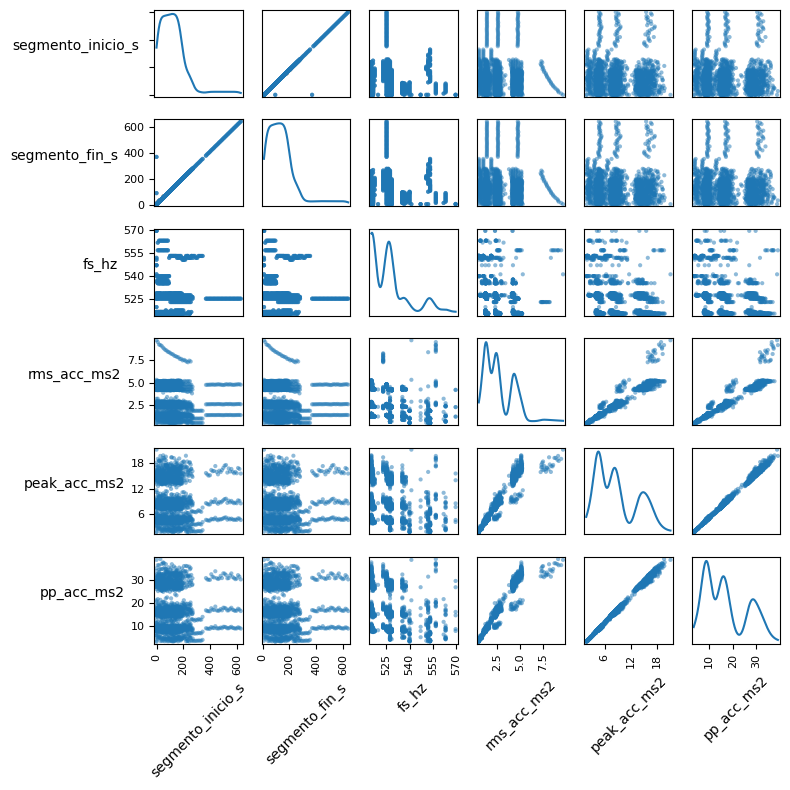

In [10]:

# === 8) Scatter-Matrix (sustituto de pairplot con matplotlib/pandas) ===
# Para evitar figuras gigantes, tomamos hasta 6 columnas numéricas representativas
sample_cols = x_cols[:6] if len(x_cols) > 6 else x_cols
if len(sample_cols) >= 2:
    fig_sm = plt.figure(figsize=(8, 8))
    axes = scatter_matrix(df[sample_cols], figsize=(8,8), diagonal='kde')

    # Ajuste de etiquetas inclinadas
    for ax in axes.flatten():
        ax.xaxis.label.set_rotation(45)
        ax.yaxis.label.set_rotation(0)
        ax.yaxis.label.set_ha('right')
        ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(4))

    fig_sm.suptitle("Scatter-Matrix (matplotlib/pandas)")
    fig_sm_path = f"{FIG_DIR}/scatter_matrix.png"
    plt.tight_layout()
    fig_sm.savefig(fig_sm_path, dpi=200, bbox_inches="tight")
    plt.close(fig_sm)
    print("Scatter-matrix guardada en:", fig_sm_path)
else:
    print("No hay suficientes columnas numéricas para scatter-matrix (se requieren ≥2).")


## Exportar todas las figuras 

Ejecuta la siguiente celda para ver y verificar la carpeta `figs/` 


In [11]:
# === 9) Empaquetar figuras en ZIP ===
import os, zipfile, glob

print("Contenido de la carpeta de figuras:")
for p in glob.glob(os.path.join(FIG_DIR, "*.png")):
    print(" -", p)

zip_path = "figs_export.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in glob.glob(os.path.join(FIG_DIR, "*.png")):
        zf.write(p, arcname=os.path.basename(p))

print("ZIP creado:", os.path.abspath(zip_path))


Contenido de la carpeta de figuras:
 - figs\confusion_matrix.png
 - figs\correlation_matrix.png
 - figs\feature_importances.png
 - figs\scatter_matrix.png
ZIP creado: c:\Users\QTMP0104\Downloads\Proyecto\Proyecto\figs_export.zip


# Convertidor
Si tiene sus propios muestros puede ignorar esta parte y simplemente juntarlos e subirlos.


In [12]:
#=== Script para balancear dataset generando datos sintéticos === :D
import pandas as pd
import numpy as np

# === CONFIGURACIÓN ===
SOURCE = "C:\\Users\\QTMP0104\\Downloads\\Proyecto\\Proyecto\\Pruebas\\features_dataset_10s.csv"
OUTPUT = "features_dataset_10s_balanced.csv"

# === CARGA ===
df = pd.read_csv(SOURCE)
print(f"Dataset original: {df.shape[0]} muestras")

# === FILTRAR LAS QUE SON INACEPTABLES ===
df_inac = df[df["severity_label"].str.contains("Inaceptable", case=False)].copy()

# === GENERAR VERSIONES ESCALADAS ===
scales = {
    "Buena (Aceptable)": 0.30,        # 30% de la amplitud original.
    "Satisfactoria (Vigilancia)": 0.55  # 55% de la amplitud original.
}

synthetic = []

for label, scale in scales.items():
    df_scaled = df_inac.copy()
    
    # Escalar magnitudes proporcionales
    for col in ["rms_acc_ms2", "peak_acc_ms2", "pp_acc_ms2", "rms_vel_mm_s", "dom_amp_mm_s"]:
        if col in df_scaled.columns:
            df_scaled[col] = df_scaled[col] * scale
    
    # Recalcular severidad según RMS de velocidad
    new_labels = []
    for v in df_scaled["rms_vel_mm_s"]:
        if v <= 2.8:
            new_labels.append("Buena (Aceptable)")
        elif v <= 4.5:
            new_labels.append("Satisfactoria (Vigilancia)")
        elif v <= 7.1:
            new_labels.append("Insatisfactoria (Crítica)")
        else:
            new_labels.append("Inaceptable (Riesgo de daño)")
    df_scaled["severity_label"] = new_labels

    # Forzar etiqueta deseada (aseguramos consistencia)
    df_scaled["severity_label"] = label
    synthetic.append(df_scaled)

# === UNIRTODO===
df_final = pd.concat([df, *synthetic], ignore_index=True)
print(f"Nuevo dataset total: {df_final.shape[0]} muestras")

# === DISTRIBUCIÓN ===
print("\nDistribución de clases:")
print(df_final["severity_label"].value_counts())

# === GUARDAR ===
df_final.to_csv(OUTPUT, index=False, encoding="utf-8-sig")
print(f"\n✅ Dataset balanceado guardado como: {OUTPUT}")


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\QTMP0104\\Downloads\\Proyecto\\Proyecto\\Pruebas\\features_dataset_10s.csv'

# Conclusión 🦜
El problema de utilizar dataset reales de este tipo es que la mayoria tienden a tener unos RMS inestables, por lo que es muy complicado tener un muestreo de motores en todas las condiciones, si usted tiene la capacidad de obtener dichos datos entonces no haria falta este ultimo paso, este esta dada la limitación en la obtención de datos, le invito a crear su proprio ML alimentado con sus datos reales y variados si es el caso, eso daria como resultado un programa inclusive mucho más confiable.

fin.

